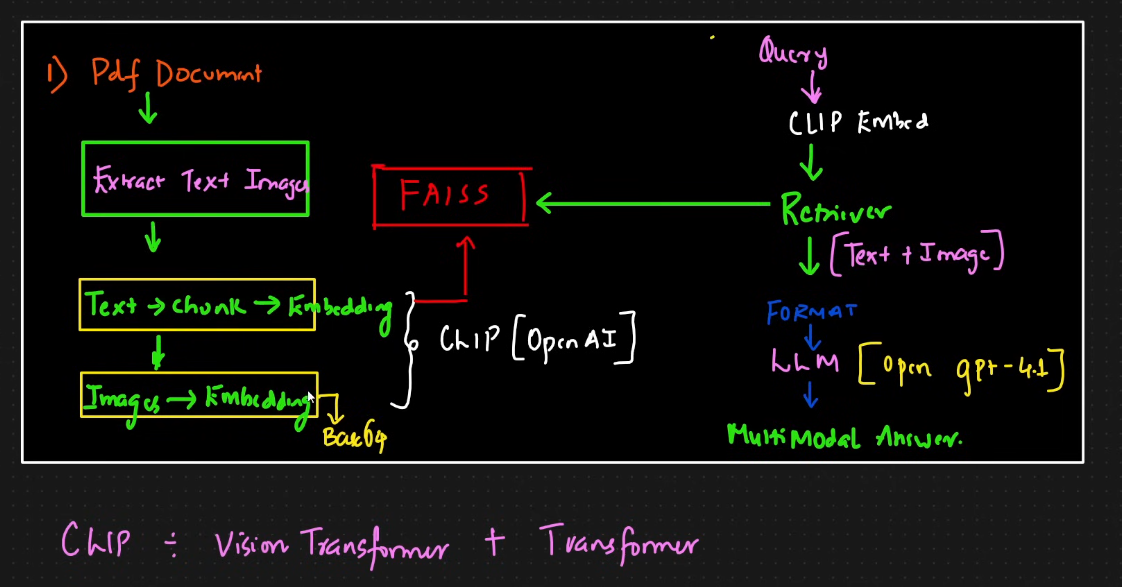

In [1]:
import fitz  # PyMuPDF
from langchain_core.documents import Document
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import numpy as np
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage
from sklearn.metrics.pairwise import cosine_similarity
import os
import base64
import io
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

d:\MyFiles\Agentic-AI\AgenticAi-LangGraph-MCP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\CSMBD\AppData\Local\Temp\ipykernel_5532\1546852462.py:15: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [2]:
import os
from dotenv import load_dotenv
from transformers import CLIPModel, CLIPProcessor

load_dotenv()
os.environ["GEMINI_API_KEY"]=os.getenv("GEMINI_API_KEY")

In [3]:
from transformers import CLIPProcessor, CLIPModel

# Initialize the Clip Model for unified embeddings
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 29930.84it/s]


CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1

In [4]:
# Embedding functions
def embed_image(image_data):
    """Embed image using CLIP"""
    if isinstance(image_data, str):  # If path
        image = Image.open(image_data).convert("RGB")
    else:  # If PIL Image
        image = image_data
    
    inputs=clip_processor(images=image,return_tensors="pt")
    with torch.no_grad():
        features = clip_model.get_image_features(**inputs).pooler_output
        
        # Normalize embeddings to unit vector
        features = features / features.norm(dim=-1, keepdim=True)
        
    return features.squeeze().numpy()
    
def embed_text(text):
    """Embed text using CLIP."""
    inputs = clip_processor(
        text=[text], 
        return_tensors="pt", 
        padding=True,
        truncation=True,
        max_length=77  # CLIP's max token length
    )
    with torch.no_grad():
        features = clip_model.get_text_features(**inputs).pooler_output
        
        # Normalize embeddings
        features = features / features.norm(dim=-1, keepdim=True)
        
    return features.squeeze().numpy()

In [5]:
## Process PDF
pdf_path="solar_panels.pdf"
doc = fitz.open(pdf_path)

# Storage for all documents and embeddings
all_docs = []
all_embeddings = []
image_data_store = {}  # Store actual image data for LLM

# Text splitter
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

In [6]:
doc

Document('solar_panels.pdf')

### Three Important Actions:

    1. Convert PDF image to PIL format
    2. Store as base64 for GPT (Which needs base64 images)
    3. Create CLIP embedding for retrieval

In [ ]:
for i,page in enumerate(doc):
    # Process text
    text=page.get_text()
    if text.strip():
        # Create temporary document for splitting
        temp_doc = Document(page_content=text, metadata={"page": i, "type": "text"})
        text_chunks = splitter.split_documents([temp_doc])

        # Embed each chunk using CLIP
        for chunk in text_chunks:
            embedding = embed_text(chunk.page_content)
            all_embeddings.append(embedding)
            all_docs.append(chunk)



    # Process images
    for img_index, img in enumerate(page.get_images(full=True)):
        try:
            xref = img[0]
            base_image = doc.extract_image(xref)
            image_bytes = base_image["image"]
            
            # Convert to PIL Image
            pil_image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
            
            # Create unique identifier
            image_id = f"page_{i}_img_{img_index}"
            
            # Store image as base64 for later use with GPT-4V
            buffered = io.BytesIO()
            pil_image.save(buffered, format="PNG")
            img_base64 = base64.b64encode(buffered.getvalue()).decode()
            image_data_store[image_id] = img_base64
            
            # Embed image using CLIP
            embedding = embed_image(pil_image)
            all_embeddings.append(embedding)
            
            # Create document for image
            image_doc = Document(
                page_content=f"[Image: {image_id}]",
                metadata={"page": i, "type": "image", "image_id": image_id}
            )
            all_docs.append(image_doc)
            
        except Exception as e:
            print(f"Error processing image {img_index} on page {i}: {e}")
            continue

doc.close()

In [8]:
all_docs

[Document(metadata={'page': 0, 'type': 'text'}, page_content='Random Topic Explainer: Solar Panels\nPage 1\nHow Solar Panels Turn Sunlight\nInto Electricity\nA beginner-friendly 3-page visual guide\nFigure 1: Sunlight hits photovoltaic cells, creating usable electrical energy.\n1. The big idea\nSolar panels use photovoltaic cells to convert light energy into electrical energy. The word\nphotovoltaic means producing voltage from light. A solar panel is not storing sunlight; it is\nconverting incoming light into electricity immediately.'),
 Document(metadata={'page': 0, 'type': 'text'}, page_content='converting incoming light into electricity immediately.\nEach panel is made of many small solar cells, usually based on silicon. When sunlight reaches\nthese cells, tiny particles of light called photons transfer energy to electrons inside the material.\nThe cell structure guides those electrons into a flowing current.\nThe electricity produced by a panel is direct current, or DC. Most homes

In [9]:
# Create unified FAISS vector store with CLIP embeddings
embeddings_array = np.array(all_embeddings)
embeddings_array

array([[-2.5240542e-02,  2.7510051e-02,  1.9551091e-02, ...,
         4.6983737e-02,  5.5529770e-02, -4.1809581e-02],
       [-3.3526253e-02, -1.6911417e-02,  5.6643961e-03, ...,
         1.5107846e-02,  4.4675365e-02, -5.3209674e-02],
       [-3.3557648e-05,  2.8299268e-02,  1.5231323e-02, ...,
        -5.8163863e-02,  2.2843644e-02,  2.3644972e-03],
       ...,
       [ 2.4390588e-02, -1.6260874e-02, -1.1717635e-02, ...,
         6.5077931e-02,  5.2819367e-02, -3.0662166e-02],
       [ 4.4973767e-03,  2.2894066e-02,  3.3019934e-02, ...,
        -5.1811945e-02,  4.5067012e-02, -8.7773958e-03],
       [-1.6570004e-02, -4.2626996e-02, -4.9535977e-03, ...,
         4.3355294e-02,  5.0662052e-02, -4.9697135e-02]],
      shape=(12, 512), dtype=float32)

In [10]:
# Create custom FAISS index since we have precomputed embeddings
vector_store = FAISS.from_embeddings(
    text_embeddings=[(doc.page_content, emb) for doc, emb in zip(all_docs, embeddings_array)],
    embedding=None,  # We're using precomputed embeddings
    metadatas=[doc.metadata for doc in all_docs]
)
vector_store

`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


In [19]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("google_genai:gemini-3.5-flash-lite")
llm

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14', 'langchain-google-genai': '4.3.2'}}, output_version=None, profile={'name': 'Gemini 3.5 Flash Lite', 'release_date': '2026-07-21', 'last_updated': '2026-07-21', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high'], 'reasoning_effort_default': 'minimal'}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.5-flash-lite', temperature=None, client=<google.genai.client.Client object at 0x000002BCE83A8

In [12]:
# response = llm.invoke("Explain AI in healthcare in 3 bullet points.")
# print(response.content)

In [13]:
def retrieve_multimodal(query, k_text=4, k_image=1):
    """Split retrieval: rank text and image documents separately, then merge.
    A single unified top-k search over both pools starves out images -- CLIP's
    text-image similarity scores are systematically much lower than its
    text-text scores (the "modality gap"), so even a perfectly relevant image
    would never outrank a mediocre text chunk in one flat ranking. Ranking each
    modality against the query independently, then combining the results,
    guarantees the best-matching image(s) always get a slot.
    """
    # Embed query using CLIP
    query_embedding = embed_text(query)
    
    def top_k(doc_type, k):
        candidates = [
            (float(np.dot(query_embedding, emb)), doc)
            for doc, emb in zip(all_docs, all_embeddings)
            if doc.metadata.get("type") == doc_type
        ]
        candidates.sort(key=lambda x: -x[0])
        return [doc for _, doc in candidates[:k]]
    
    return top_k("text", k_text) + top_k("image", k_image)

In [ ]:
def create_multimodal_message(query, retrieved_docs):
    """Create a message with both text and images for GPT"""
    content = []
    
    # Add the query
    content.append({
        "type": "text",
        "text": f"Question: {query}\n\nContext:\n"
    })
    
    # Separate text and image documents
    text_docs = [doc for doc in retrieved_docs if doc.metadata.get("type") == "text"]
    image_docs = [doc for doc in retrieved_docs if doc.metadata.get("type") == "image"]
    
    # Add text context
    if text_docs:
        text_context = "\n\n".join([
            f"[Page {doc.metadata['page']}]: {doc.page_content}"
            for doc in text_docs
        ])
        content.append({
            "type": "text",
            "text": f"Text excerpts:\n{text_context}\n"
        })
    
    # Add images
    for doc in image_docs:
        image_id = doc.metadata.get("image_id")
        if image_id and image_id in image_data_store:
            content.append({
                "type": "text",
                "text": f"\n[Image from page {doc.metadata['page']}]:\n"
            })
            content.append({
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{image_data_store[image_id]}"
                }
            })
    
    # Add instruction
    content.append({
        "type": "text",
        "text": "\n\nPlease answer the question based on the provided text and images."
    })
    
    return HumanMessage(content=content)

In [15]:
def multimodal_pdf_rag_pipeline(query):
    """Main pipeline for multimodal RAG."""
    
    # Retrieve relevant documents
    context_docs = retrieve_multimodal(query)
    
    # Create multimodal message
    message = create_multimodal_message(query, context_docs)
    
    # Get response from GPT-4V
    response = llm.invoke([message])
    
    # Print retrieved context info
    print(f"\nRetrieved {len(context_docs)} documents:")
    for doc in context_docs:
        doc_type = doc.metadata.get("type", "unknown")
        page = doc.metadata.get("page", "?")
        if doc_type == "text":
            preview = doc.page_content[:100] + "..." if len(doc.page_content) > 100 else doc.page_content
            print(f"  - Text from page {page}: {preview}")
        else:
            print(f"  - Image from page {page}")
    print("\n")
    
    return response.content

In [ ]:
if __name__ == "__main__":
    # Example queries
    queries = [
        "How do solar panels convert sunlight into electricity?",
        "From Figure 1, what happens when sunlight hits the photovoltaic cells?",
        "From Figure 3, what components are shown in a basic home solar system?"
    ]
    
    for query in queries:
        print(f"\nQuery: {query}")
        print("-" * 50)
        answer = multimodal_pdf_rag_pipeline(query)
        print(f"Answer: {answer}")
        print("=" * 70)


Query: How do solar panels convert sunlight into electricity?
--------------------------------------------------

Retrieved 5 documents:
  - Text from page 2: Solar panels are a clean way to turn sunlight into electricity. The best system uses good
placement,...
  - Text from page 0: The electricity produced by a panel is direct current, or DC. Most homes use alternating current,
or...
  - Text from page 1: batteries, or send excess electricity to the grid where supported.
Important note
Solar output chang...
  - Text from page 0: converting incoming light into electricity immediately.
Each panel is made of many small solar cells...
  - Image from page 0


Answer: [{'type': 'text', 'text': 'Based on the provided text and image, solar panels convert sunlight into electricity through the following process:\n\n1. **Light Capture:** Each solar panel is made of many small solar cells (usually based on silicon) that capture incoming sunlight [Page 0].\n2. **Energy Transfer:** When sunlight 

: 